In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("survey_data.csv");
df
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h2>Handling Missing Dataset</h2>


In [4]:
df[['Employment','JobSat','RemoteWork']].isnull().sum()
df['Employment'].fillna(df['Employment'].mode()[0],inplace=True)
df['RemoteWork'].fillna(df['RemoteWork'].mode()[0],inplace=True)

df['JobSat'].fillna(df['JobSat'].median(),inplace=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_8312\1373079862.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Employment'].fillna(df['Employment'].mode()[0],inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_8312\1373079862.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [5]:
# Convert YearsCodePro to numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Create experience ranges
bins = [0, 5, 10, 20, 100]
labels = ['0-5', '5-10', '10-20', '>20']

df['ExperienceRange'] = pd.cut(
    df['YearsCodePro'],
    bins=bins,
    labels=labels,
    right=False
)

# Median Job Satisfaction
median_jobsat = df.groupby('ExperienceRange')['JobSat'].median()

print(median_jobsat)

ExperienceRange
0-5      7.0
5-10     7.0
10-20    7.0
>20      7.0
Name: JobSat, dtype: float64


C:\Users\dell\AppData\Local\Temp\ipykernel_8312\3995599559.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_jobsat = df.groupby('ExperienceRange')['JobSat'].median()


<h3>Job Satisfaction Visualisation</h3>

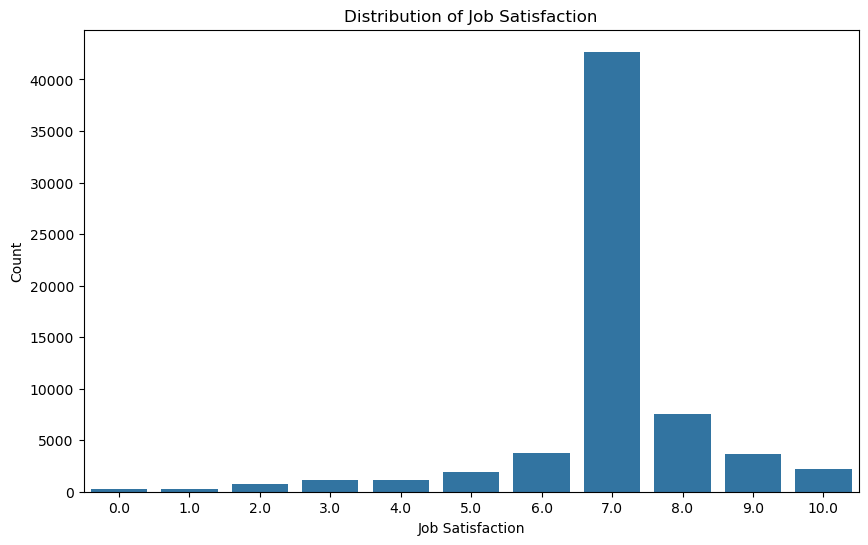

In [23]:

# Count plot for Job Satisfaction
plt.figure(figsize=(10,6))

sns.countplot(data=df, x='JobSat')

plt.title('Distribution of Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Count')

plt.show()

<h3>Analyzing Remote Work Preferences by Job Role</h3>

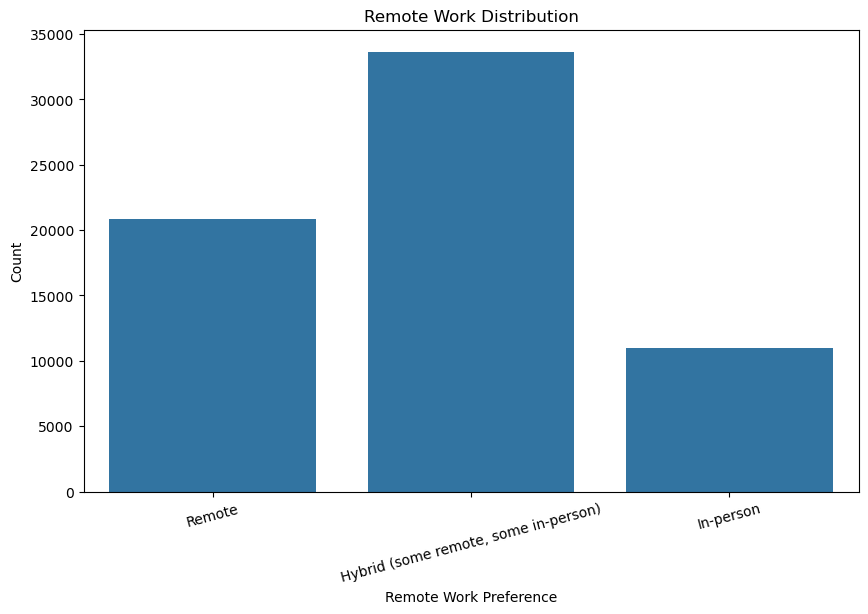

RemoteWork                                          Hybrid (some remote, some in-person)  \
Employment                                                                                 
Employed, full-time                                                                17296   
Employed, full-time;Employed, part-time                                               85   
Employed, full-time;Independent contractor, fre...                                  1330   
Employed, full-time;Independent contractor, fre...                                    80   
Employed, full-time;Independent contractor, fre...                                     0   
...                                                                                  ...   
Student, full-time;Student, part-time;Employed,...                                     4   
Student, full-time;Student, part-time;Retired                                          2   
Student, part-time                                                              

In [10]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x='RemoteWork')

plt.title('Remote Work Distribution')
plt.xlabel('Remote Work Preference')
plt.ylabel('Count')

plt.xticks(rotation=15)
plt.show()

# Cross-tabulation of RemoteWork and Employment
remote_employment = pd.crosstab(df['Employment'], df['RemoteWork'])

print(remote_employment)

<h3>Analyzing Programming Language Trends by Region
</h3>

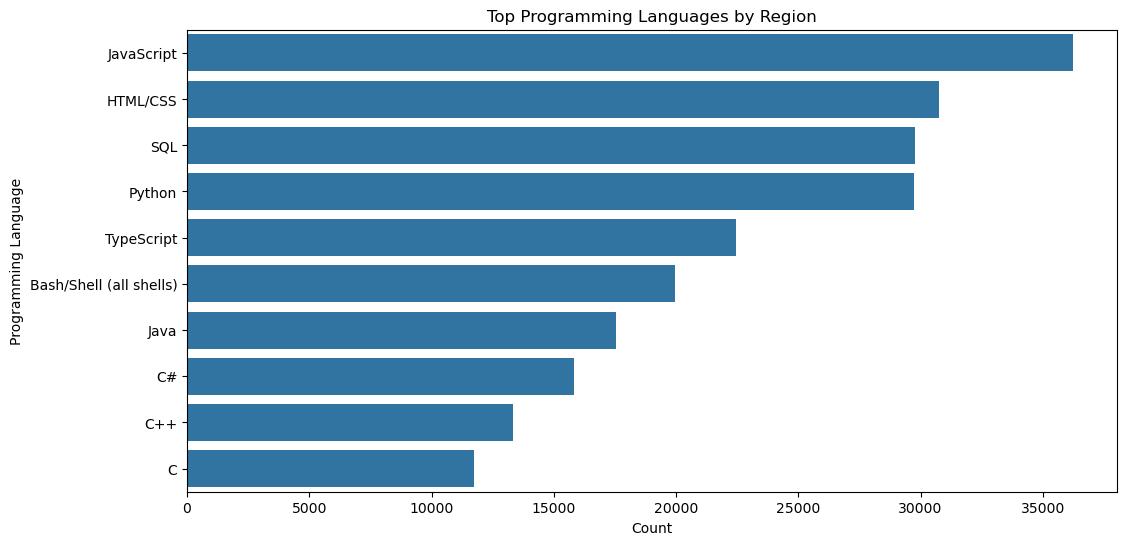

In [11]:
# Filter rows with non-null language data
lang_df = df[['Country', 'LanguageHaveWorkedWith']].dropna()

# Split multiple languages into separate rows
lang_df['LanguageHaveWorkedWith'] = lang_df['LanguageHaveWorkedWith'].str.split(';')
lang_df = lang_df.explode('LanguageHaveWorkedWith')

# Find top 10 languages overall
top_languages = lang_df['LanguageHaveWorkedWith'].value_counts().head(10).index

# Keep only top languages
filtered_lang_df = lang_df[
    lang_df['LanguageHaveWorkedWith'].isin(top_languages)
]

# Plot language popularity
plt.figure(figsize=(12,6))

sns.countplot(
    data=filtered_lang_df,
    y='LanguageHaveWorkedWith',
    order=filtered_lang_df['LanguageHaveWorkedWith'].value_counts().index
)

plt.title('Top Programming Languages by Region')
plt.xlabel('Count')
plt.ylabel('Programming Language')

plt.show()

<h3>Correlation Between Experience and Satisfaction</h3>

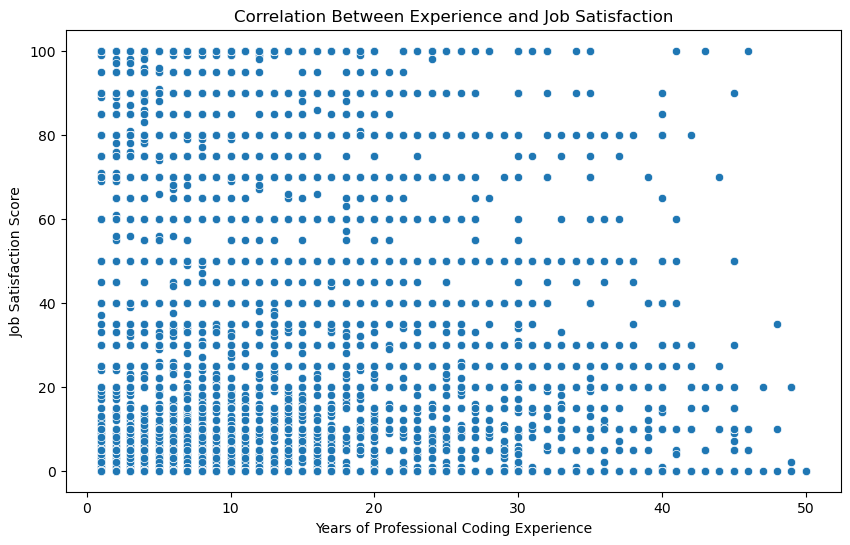

Correlation: -0.032846409296354726


In [13]:
# Convert YearsCodePro to numeric
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Scatter plot for Experience vs Job Satisfaction
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='YearsCodePro',
    y='JobSatPoints_1'
)

plt.title('Correlation Between Experience and Job Satisfaction')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Job Satisfaction Score')

plt.show()

# Correlation value
correlation = df['YearsCodePro'].corr(df['JobSatPoints_1'])

print("Correlation:", correlation)

<h3>Educational Background and Employment Type</h3>

Employment                                          Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                1059   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      16806   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                   11011   
Primary/elementary school                                           160   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     2073   
Secondary school (e.g. American high school, Ge...                 1460   
Some college/university study without earning a...                 3579   
Something else                                                      377   

Employment                                          Employed, full-time;Employed, part-time  \
EdLevel                                                                                       
Associate degree (A.A., A.S., etc.)                        

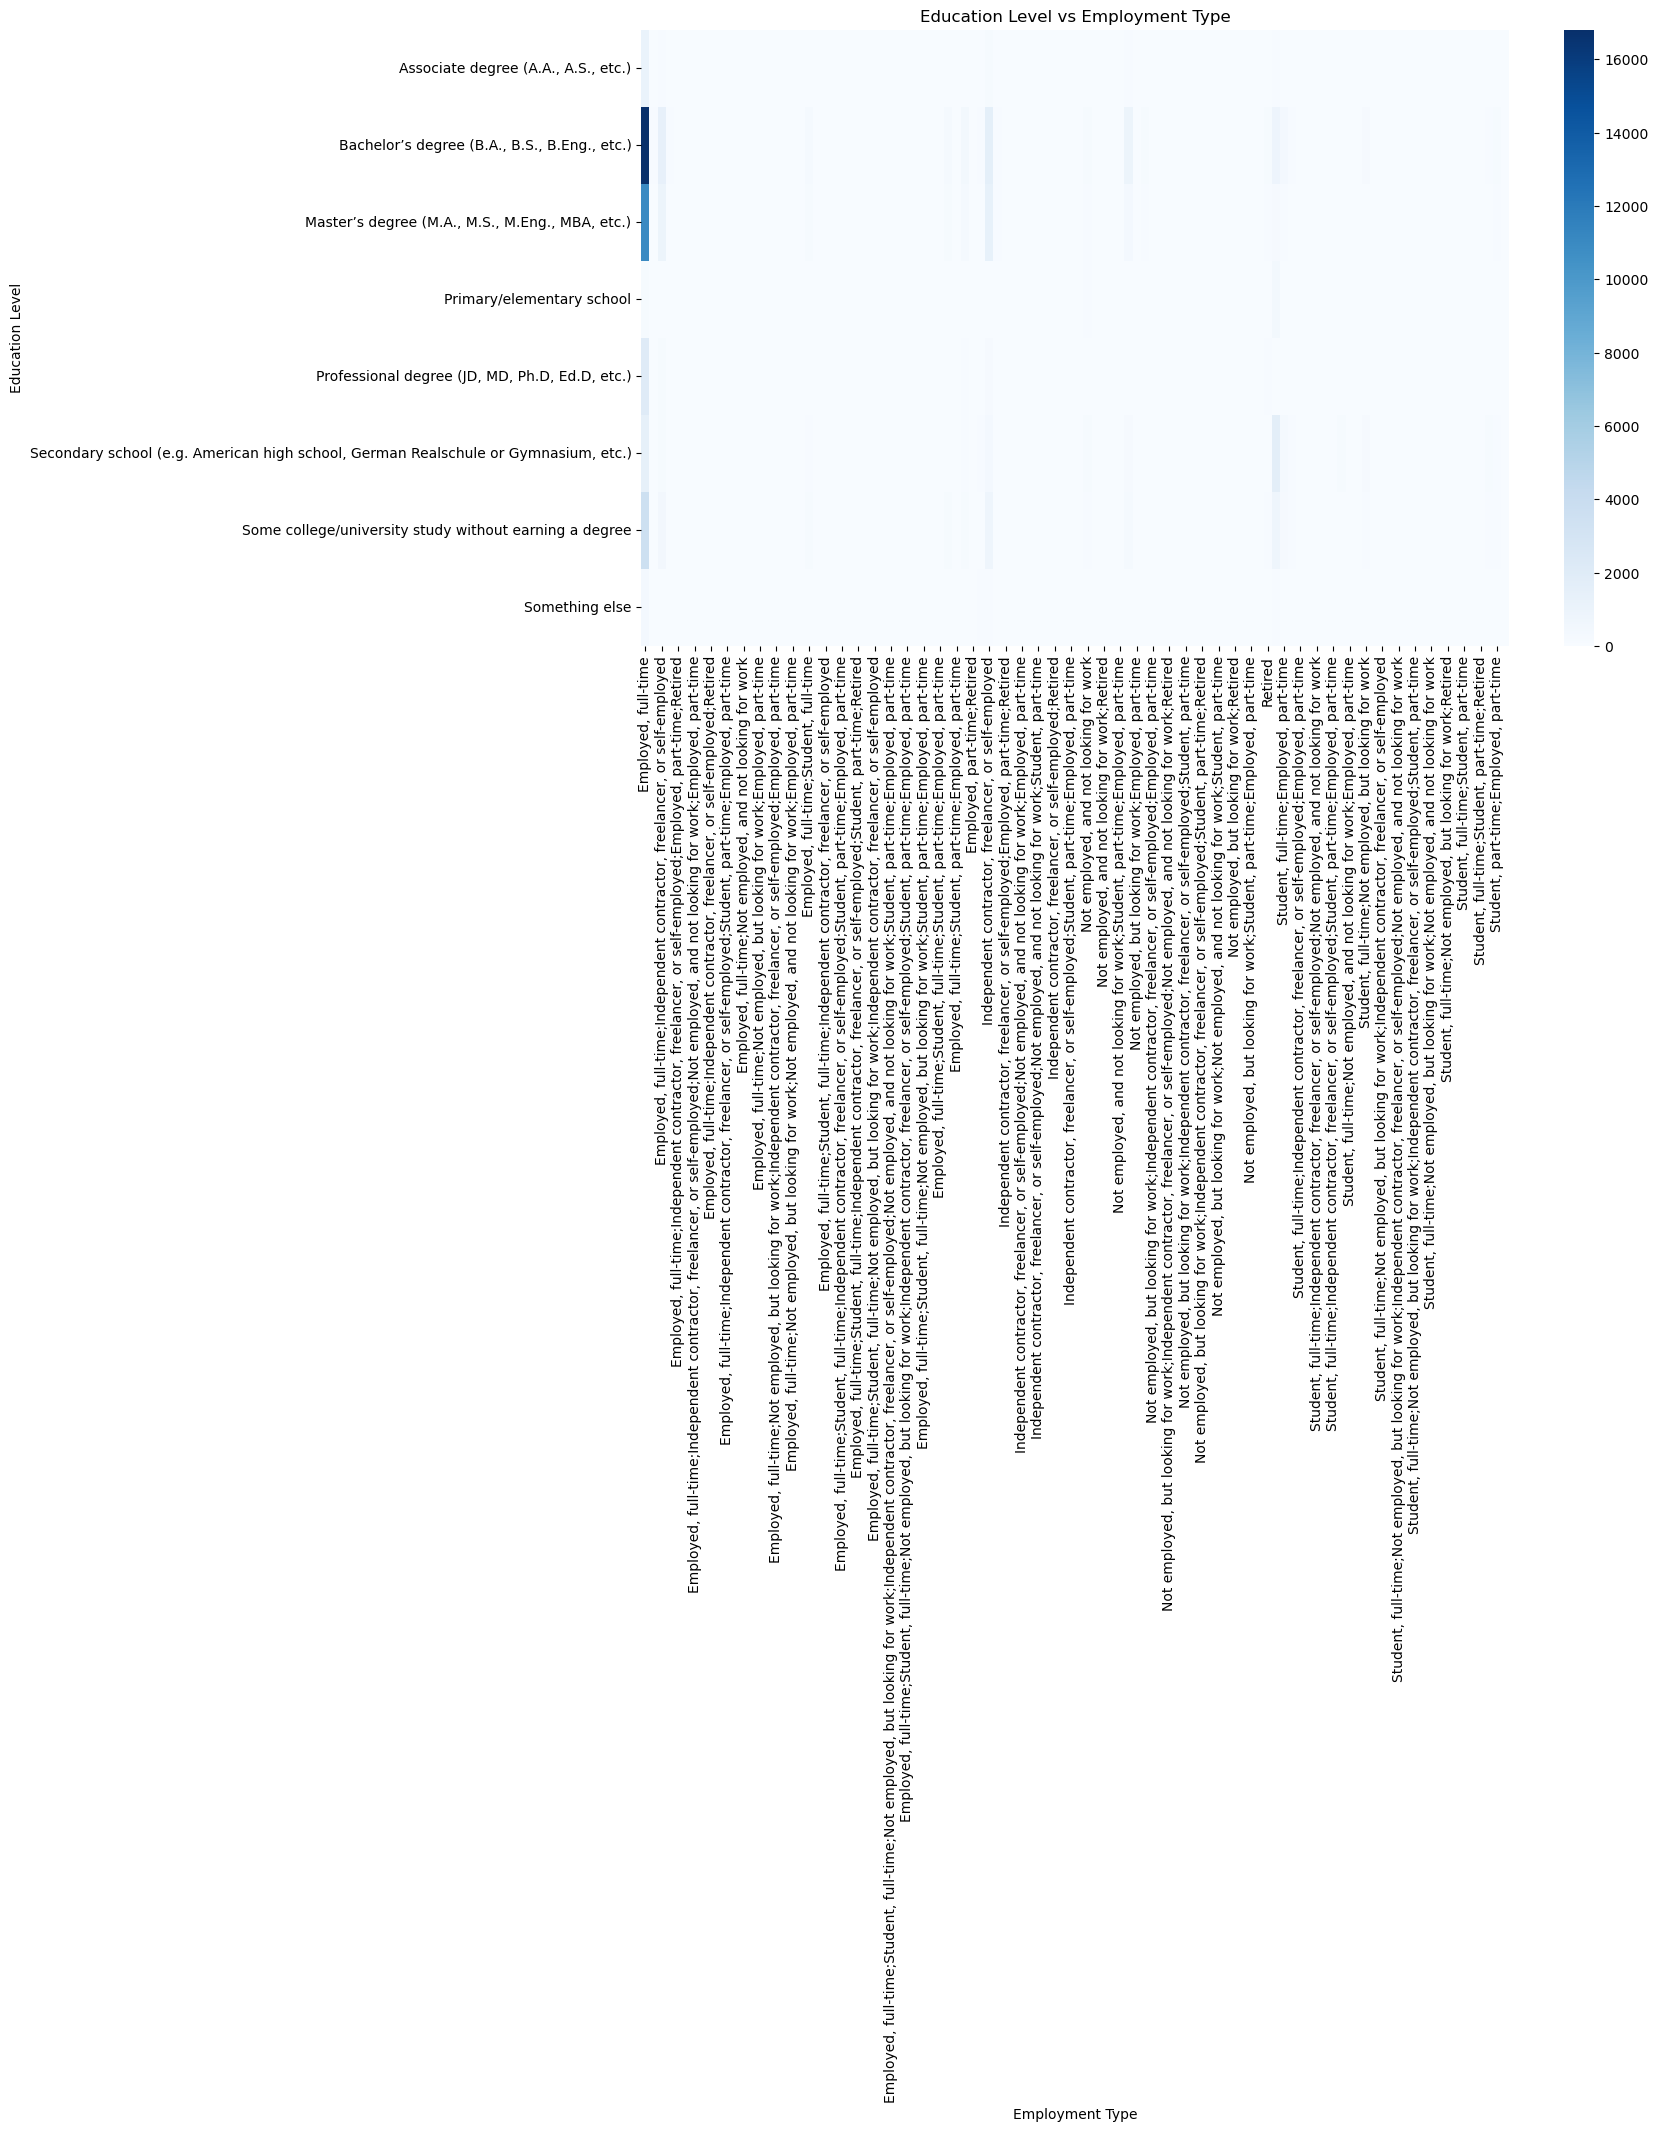

In [14]:
# Cross-tabulation between Education Level and Employment Type
edu_employment = pd.crosstab(df['EdLevel'], df['Employment'])

print(edu_employment)

# Visualize using heatmap
plt.figure(figsize=(14,8))

sns.heatmap(edu_employment, cmap='Blues')

plt.title('Education Level vs Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Education Level')

plt.show()

In [15]:
# Save cleaned and analyzed dataset
df.to_csv('cleaned_analyzed_dataset.csv', index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


<h3>Finding Outliers</h3>

<h4>Plot the Distribution of Industry</h4>

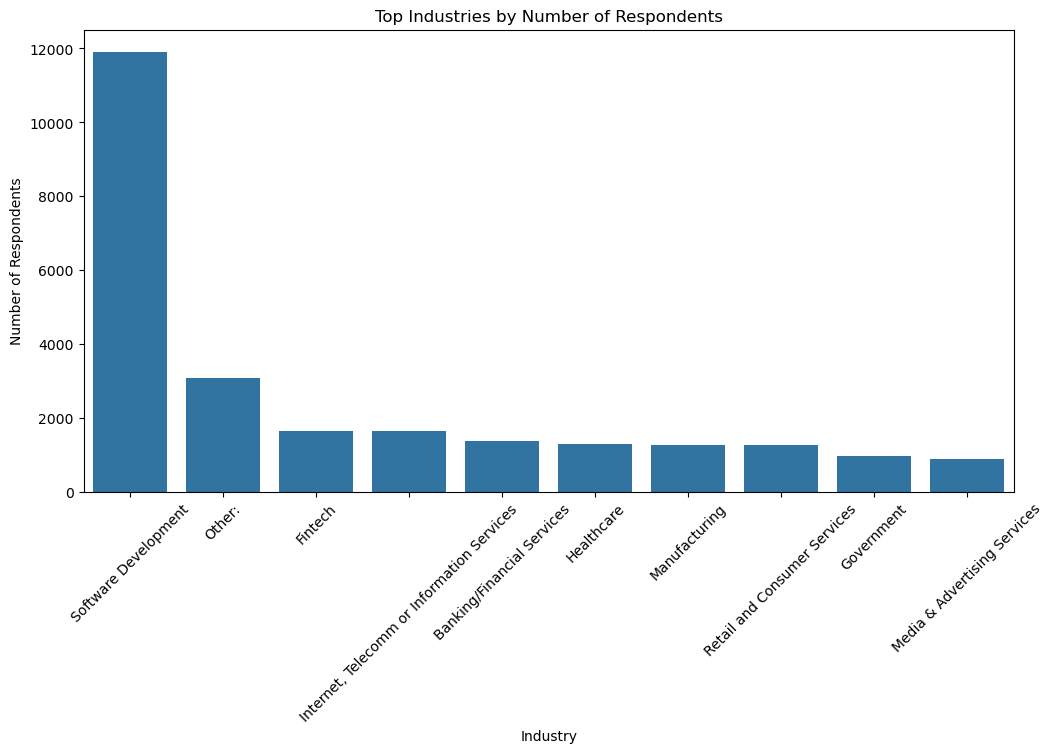

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64


In [16]:

# Count respondents by industry
industry_counts = df['Industry'].value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    x=industry_counts.index,
    y=industry_counts.values
)

plt.title('Top Industries by Number of Respondents')
plt.xlabel('Industry')
plt.ylabel('Number of Respondents')

plt.xticks(rotation=45)
plt.show()

# Display counts
print(industry_counts)

<h4>Identify High Compensation Outliers</h4>

In [17]:
# Basic statistics
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print("Mean Compensation:", mean_comp)
print("Median Compensation:", median_comp)
print("Standard Deviation:", std_comp)

# Define threshold for outliers
threshold = mean_comp + (3 * std_comp)

# Identify high compensation outliers
outliers = df[df['ConvertedCompYearly'] > threshold]

print("Number of Outliers:", len(outliers))

# Display top outliers
print(outliers[['ConvertedCompYearly']].head())

Mean Compensation: 86155.28726264134
Median Compensation: 65000.0
Standard Deviation: 186756.9730862951
Number of Outliers: 89
      ConvertedCompYearly
529              650000.0
828             1000000.0
1932             945000.0
2171             750000.0
2187            2000000.0


<h4>Detect Outliers in Compensation</h4>

Lower Bound: -80177.25
Upper Bound: 220860.75
Number of Outliers: 978


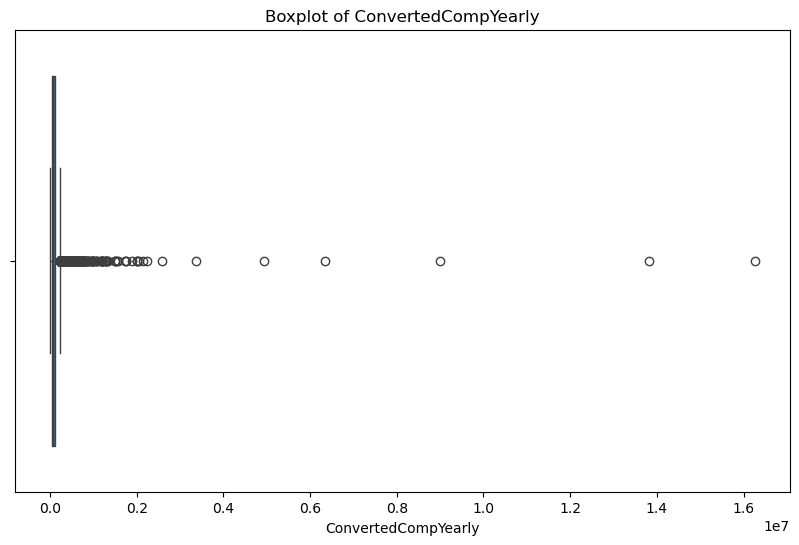

In [18]:
# Calculate Q1 and Q3
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
outliers = df[
    (df['ConvertedCompYearly'] < lower_bound) |
    (df['ConvertedCompYearly'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

# Boxplot visualization
plt.figure(figsize=(10,6))

sns.boxplot(x=df['ConvertedCompYearly'])

plt.title('Boxplot of ConvertedCompYearly')

plt.show()

<h4> Remove Outliers and Create a New DataFrame</h4>

In [19]:
# Remove outliers
df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

# Validate new dataframe size
print("Original DataFrame Shape:", df.shape)
print("New DataFrame Shape:", df_no_outliers.shape)

Original DataFrame Shape: (65437, 115)
New DataFrame Shape: (22457, 115)


<h4> Correlation Analysis</h4>


AgeNumeric             1.000000
WorkExp                0.849016
YearsCodePro           0.828368
ConvertedCompYearly    0.122096
JobSat                 0.038129
CompTotal             -0.002700
JobSatPoints_1        -0.027742
ResponseId            -0.038205
JobSatPoints_8        -0.046294
JobSatPoints_6        -0.050103
JobSatPoints_4        -0.076098
JobSatPoints_9        -0.081799
JobSatPoints_7        -0.083297
JobSatPoints_5        -0.101611
JobSatPoints_11       -0.107228
JobSatPoints_10       -0.114583
Name: AgeNumeric, dtype: float64


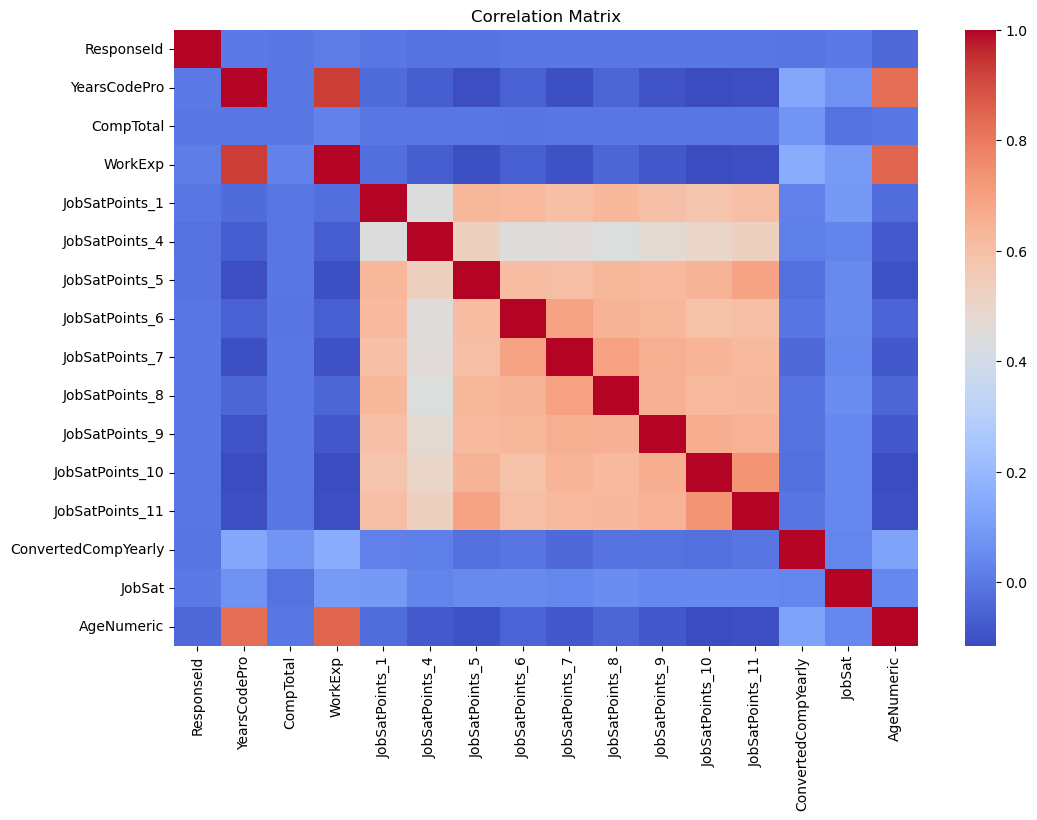

In [20]:
# Map Age categories to approximate numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

# Create numeric age column
df['AgeNumeric'] = df['Age'].map(age_mapping)

# Select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Display correlations with AgeNumeric
print(correlation_matrix['AgeNumeric'].sort_values(ascending=False))

# Visualize correlation matrix
plt.figure(figsize=(12,8))

sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.title('Correlation Matrix')

plt.show()

<h3>Finding Correlation</h3>

<h4>Analyze and Visualize Compensation Distribution</h4>

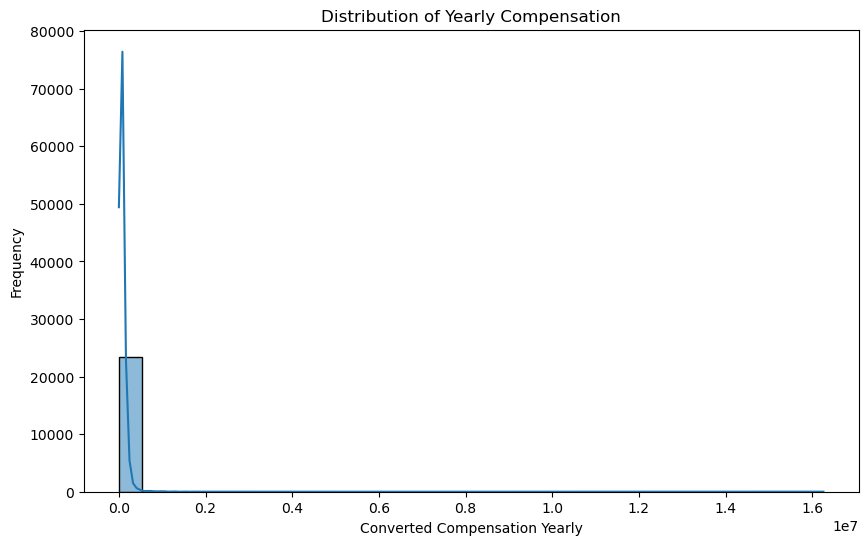

In [22]:


# Remove missing values
comp_data = df['ConvertedCompYearly'].dropna()

# Plot histogram
plt.figure(figsize=(10,6))

sns.histplot(comp_data, bins=30, kde=True)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('Converted Compensation Yearly')
plt.ylabel('Frequency')

plt.show()

<h4>Calculate Median Compensation for Full-Time Employees</h4>

In [24]:
# Filter full-time employees
full_time_df = df[df['Employment'] == 'Employed, full-time']

# Calculate median compensation
median_comp = full_time_df['ConvertedCompYearly'].median()

print("Median Compensation for Full-Time Employees:", median_comp)

Median Compensation for Full-Time Employees: 69814.0


<h4>Analyzing Compensation Range and Distribution by Country</h4>

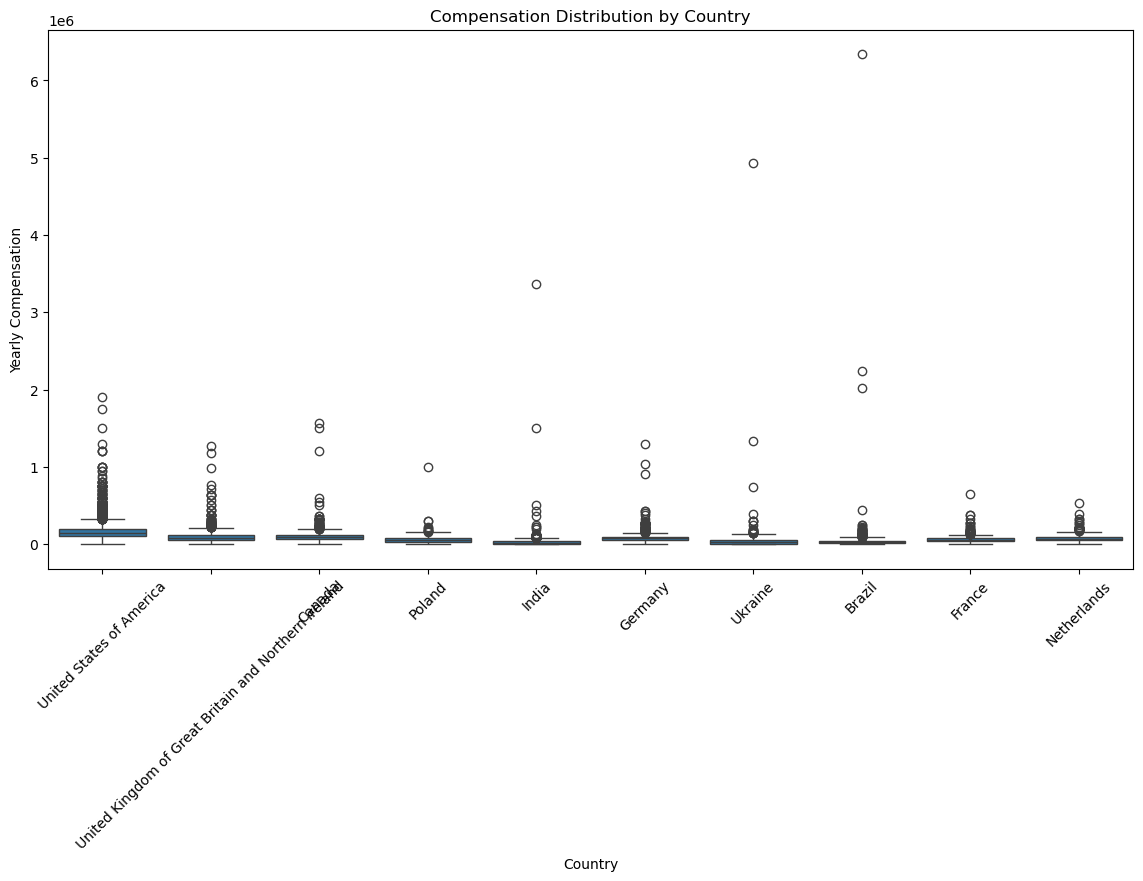

In [25]:
# Select top 10 countries by respondent count
top_countries = df['Country'].value_counts().head(10).index

country_df = df[df['Country'].isin(top_countries)]

# Boxplot of compensation by country
plt.figure(figsize=(14,7))

sns.boxplot(
    data=country_df,
    x='Country',
    y='ConvertedCompYearly'
)

plt.title('Compensation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Yearly Compensation')

plt.xticks(rotation=45)
plt.show()

<h4>Removing Outliers from the Dataset</h4>

In [26]:
# Remove outliers using IQR method
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create refined dataframe
df_clean = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
]

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (65437, 116)
Cleaned Shape: (22457, 116)


<h4>Finding Correlations Between Key Variables</h4>

                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.406993       -0.059643
WorkExp                         0.406993  1.000000       -0.032388
JobSatPoints_1                 -0.059643 -0.032388        1.000000


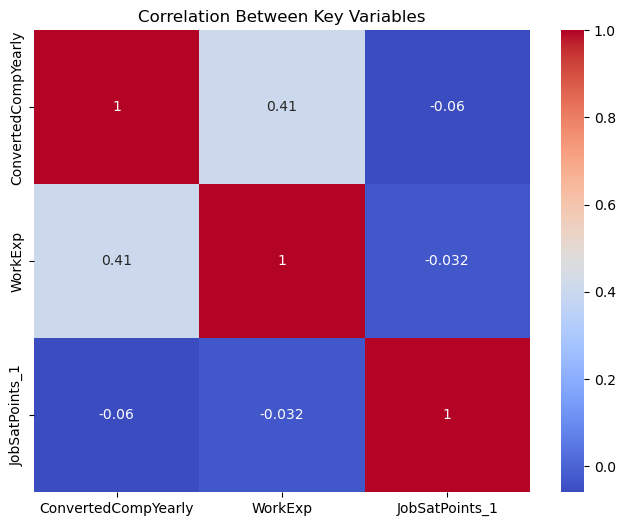

In [27]:
# Select important numeric columns
corr_df = df_clean[
    ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
].dropna()

# Correlation matrix
corr_matrix = corr_df.corr()

print(corr_matrix)

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation Between Key Variables')

plt.show()

<h4>Scatter Plot for Correlations</h4>

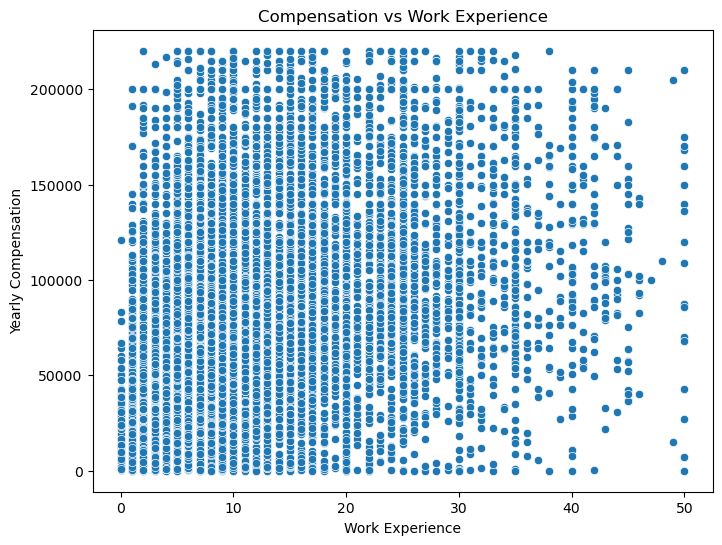

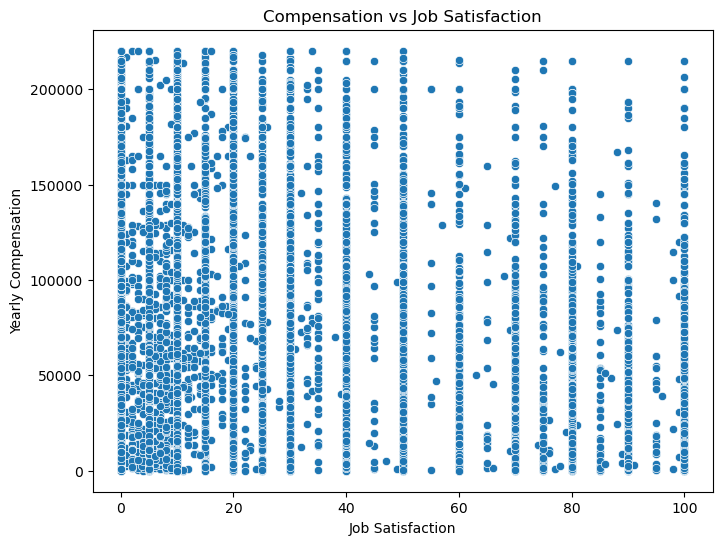

In [28]:
# Scatter plot: Compensation vs Work Experience
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='WorkExp',
    y='ConvertedCompYearly'
)

plt.title('Compensation vs Work Experience')
plt.xlabel('Work Experience')
plt.ylabel('Yearly Compensation')

plt.show()

# Scatter plot: Compensation vs Job Satisfaction
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='JobSatPoints_1',
    y='ConvertedCompYearly'
)

plt.title('Compensation vs Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Yearly Compensation')

plt.show()